<a href="https://colab.research.google.com/github/DaniloDuque/neural-network/blob/main/src/tp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP3 — Redes Neuronales

Este notebook está organizado en tres secciones principales:

1. **Two Moons** — clasificación binaria no lineal para verificar la capacidad del MLP.
2. **Clasificador en R²** — 4 configuraciones de MLP (M=20/2, con/sin momentum) sobre datos separables y no separables.
3. **ACRIMA** — clasificación de imágenes de fondo de ojo (glaucoma vs. no glaucoma).

**Modelo:** Perceptrón Multicapa con descenso de gradiente con momentum (Bishop, 2006).  
**Configuraciones evaluadas:** M ∈ {2, 20}, γ ∈ {0.0, 0.9}, α = 0.01.

## Configuración del entorno

Se clona el repositorio si se ejecuta en Google Colab, se agrega `src/` al path de Python y se configuran las credenciales de Kaggle necesarias para la Sección 3.

In [1]:
## @brief Configura el entorno de ejecución (Colab o local).
#  Clona el repositorio si se ejecuta en Google Colab y ajusta el directorio de trabajo.
import os, sys

if 'google.colab' in sys.modules:
    if not os.path.exists('neural-network'):
        os.system('git clone https://github.com/DaniloDuque/neural-network.git')
    if os.path.basename(os.getcwd()) != 'neural-network':
        os.chdir('neural-network')
    os.system('git pull')

sys.path.insert(0, os.path.abspath('src'))

In [2]:
## @brief Configura credenciales de Kaggle (Colab o local).
#  Requerido para descargar el dataset ACRIMA en la Sección 3.
#  En Colab: sube kaggle.json cuando aparezca el selector.
#  En local: colócalo en ~/.config/kaggle/kaggle.json
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import files
    print('Sube tu archivo kaggle.json:')
    uploaded = files.upload()
    os.makedirs(os.path.expanduser('~/.config/kaggle'), exist_ok=True)
    os.rename('kaggle.json', os.path.expanduser('~/.config/kaggle/kaggle.json'))
    os.chmod(os.path.expanduser('~/.config/kaggle/kaggle.json'), 0o600)
    print('Credenciales configuradas.')
else:
    kaggle_cfg   = os.path.expanduser('~/.config/kaggle/kaggle.json')
    kagglehub_cache = os.path.expanduser('~/.cache/kagglehub/datasets/toaharahmanratul/acrima-dataset')
    if os.path.exists(kaggle_cfg):
        print(f'Credenciales encontradas en {kaggle_cfg}')
    elif os.path.exists(kagglehub_cache):
        print('Dataset ACRIMA ya en caché local — no se requieren credenciales.')
    else:
        print('ADVERTENCIA: no se encontró kaggle.json en ~/.config/kaggle/kaggle.json')
        print('Descárgalo desde https://www.kaggle.com/settings → API → Create New Token')

Dataset ACRIMA ya en caché local — no se requieren credenciales.


## Dependencias

Se instalan las dependencias necesarias para ejecutar el notebook.

In [3]:
## @brief Instala dependencias del proyecto.
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install', '--upgrade',
                'torch', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas',
                'kagglehub==0.3.13', 'Pillow', '-q'],
               check=True)


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


CompletedProcess(args=['/usr/local/bin/python3', '-m', 'pip', 'install', '--upgrade', 'torch', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'kagglehub==0.3.13', 'Pillow', '-q'], returncode=0)

## Dependencias e importaciones

Se importan todos los módulos del proyecto y se detecta el dispositivo de cómputo.

In [4]:
## @brief Importa todos los módulos del proyecto y configura el entorno.
#  Detecta el dispositivo disponible (CUDA o CPU) para pasarlo a las funciones de biblioteca.
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
from PIL import Image
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import kagglehub

from multilayer_perceptron import MultilayerPerceptron
from data_generator        import generate_data
from data_classifier       import train_all_configs
from visualization         import (plot_datasets, plot_error_matrix,
                                   print_convergence_table, convergence_dataframe)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

FIGURES_DIR = Path('..') / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

Dispositivo: cpu


---
# Sección 1 — Two Moons: Clasificación Binaria No Lineal

Demostración del MLP sobre el dataset Two Moons para verificar que la red aprende fronteras de decisión no lineales.

In [5]:
## @brief Entrena MLP sobre Two Moons y visualiza la superficie de decisión.
torch.manual_seed(7)

X_np, y_np = make_moons(n_samples=400, noise=0.15, random_state=42)
X_np = (X_np - X_np.min(0)) / (X_np.max(0) - X_np.min(0))
X_moons = torch.FloatTensor(X_np).to(device)
T_moons = torch.FloatTensor(y_np).unsqueeze(1).to(device)

mlp_moons = MultilayerPerceptron([2, 128, 1], alpha=1.5, gamma=0.95, max_weights=0.01)
mlp_moons.Wo       = mlp_moons.Wo.to(device)
mlp_moons.Ws       = mlp_moons.Ws.to(device)
mlp_moons.dWo_prev = mlp_moons.dWo_prev.to(device)
mlp_moons.dWs_prev = mlp_moons.dWs_prev.to(device)

errors, _ = mlp_moons.train_mlp(50000, X_moons, T_moons)

acc = (mlp_moons.predict(X_moons).squeeze().cpu() == torch.tensor(y_np)).float().mean().item()
print(f'Error final: {errors[-1]:.4f}  |  Accuracy: {acc*100:.1f}%')

Error final: 0.0060  |  Accuracy: 99.3%


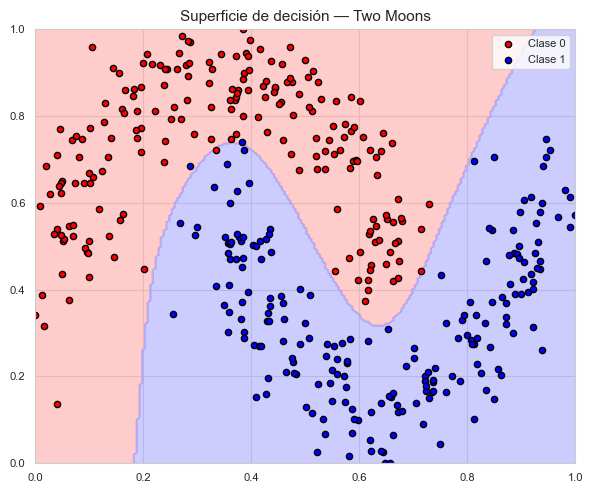

In [6]:
## @brief Visualiza la superficie de decisión del MLP sobre Two Moons.
h = 0.005
xx, yy = np.meshgrid(np.arange(0, 1 + h, h), np.arange(0, 1 + h, h))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
Z = mlp_moons.predict(grid).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']), alpha=0.6)
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], c='red',  label='Clase 0', edgecolors='k', s=20)
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], c='blue', label='Clase 1', edgecolors='k', s=20)
plt.title('Superficie de decisión — Two Moons')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'two_moons.pdf', bbox_inches='tight')
plt.show()

---
# Sección 2 — Clasificador de datos en R²

Se generan dos datasets (separable / no-separable) y se entrenan 4 configuraciones de MLP:

| Config | M  | γ   | Descripción               |
|--------|----|-----|---------------------------|
| A      | 20 | 0.9 | 20 neuronas, con momentum |
| B      | 20 | 0.0 | 20 neuronas, sin momentum |
| C      | 2  | 0.9 | 2 neuronas, con momentum  |
| D      | 2  | 0.0 | 2 neuronas, sin momentum  |

Partición 80% entrenamiento / 20% validación. α = 0.01 fijo para todas las configuraciones.

In [7]:
## @brief Define hiperparámetros globales para la sección 2.
NUM_EPOCHS = 50

## 2.1 — Generación de datos

In [8]:
## @brief Genera los datasets separable y no-separable con split 80/20.
X_train_s, X_val_s, T_train_s, T_val_s = generate_data(
    separable=True,  n_samples=500, test_size=0.2, random_state=42,
    device=torch.device(device)
)
X_train_ns, X_val_ns, T_train_ns, T_val_ns = generate_data(
    separable=False, n_samples=500, test_size=0.2, random_state=42,
    device=torch.device(device)
)

print(f'Separable    — train: {X_train_s.shape},  val: {X_val_s.shape}')
print(f'No-separable — train: {X_train_ns.shape}, val: {X_val_ns.shape}')

Separable    — train: torch.Size([400, 2]),  val: torch.Size([100, 2])
No-separable — train: torch.Size([400, 2]), val: torch.Size([100, 2])


## 2.2 — Visualización de los datos

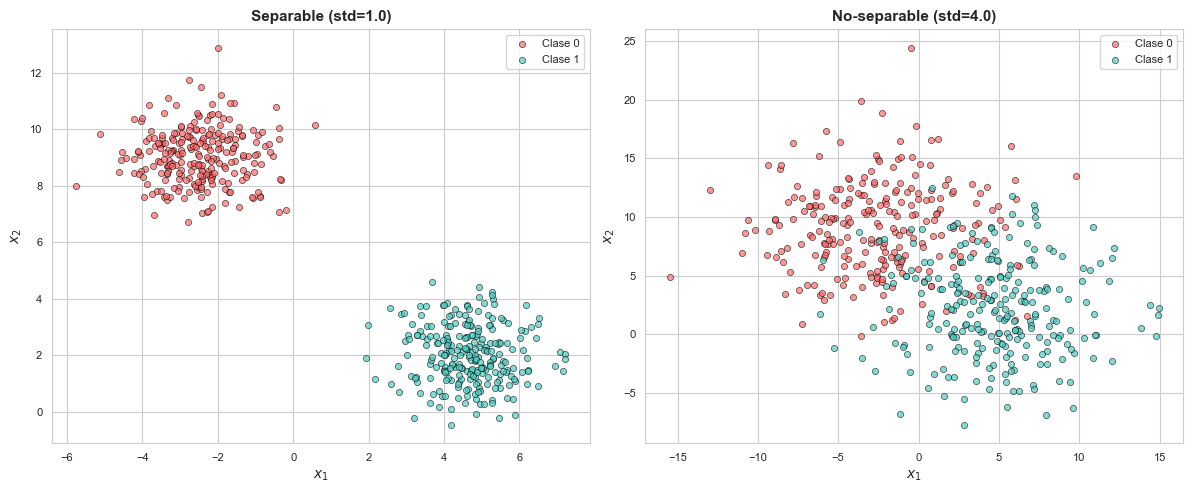

In [9]:
## @brief Muestra scatter de ambos datasets (train + val combinados).
X_sep_full   = torch.cat([X_train_s,  X_val_s],  dim=0).cpu()
T_sep_full   = torch.cat([T_train_s,  T_val_s],  dim=0).cpu()
X_nosep_full = torch.cat([X_train_ns, X_val_ns], dim=0).cpu()
T_nosep_full = torch.cat([T_train_ns, T_val_ns], dim=0).cpu()

fig = plot_datasets(X_sep_full, T_sep_full, X_nosep_full, T_nosep_full,
                    output_path=FIGURES_DIR / 'datasets_scatter.pdf')
plt.show()

## 2.3 — Entrenamiento de las 4 configuraciones

In [10]:
## @brief Entrena las 4 configuraciones sobre el dataset separable.
results_sep = train_all_configs(
    X_train_s, T_train_s, X_val_s, T_val_s,
    num_epochs=NUM_EPOCHS, device=torch.device(device)
)

In [11]:
## @brief Entrena las 4 configuraciones sobre el dataset no-separable.
results_nosep = train_all_configs(
    X_train_ns, T_train_ns, X_val_ns, T_val_ns,
    num_epochs=NUM_EPOCHS, device=torch.device(device)
)

## 2.4 — Evolución del error

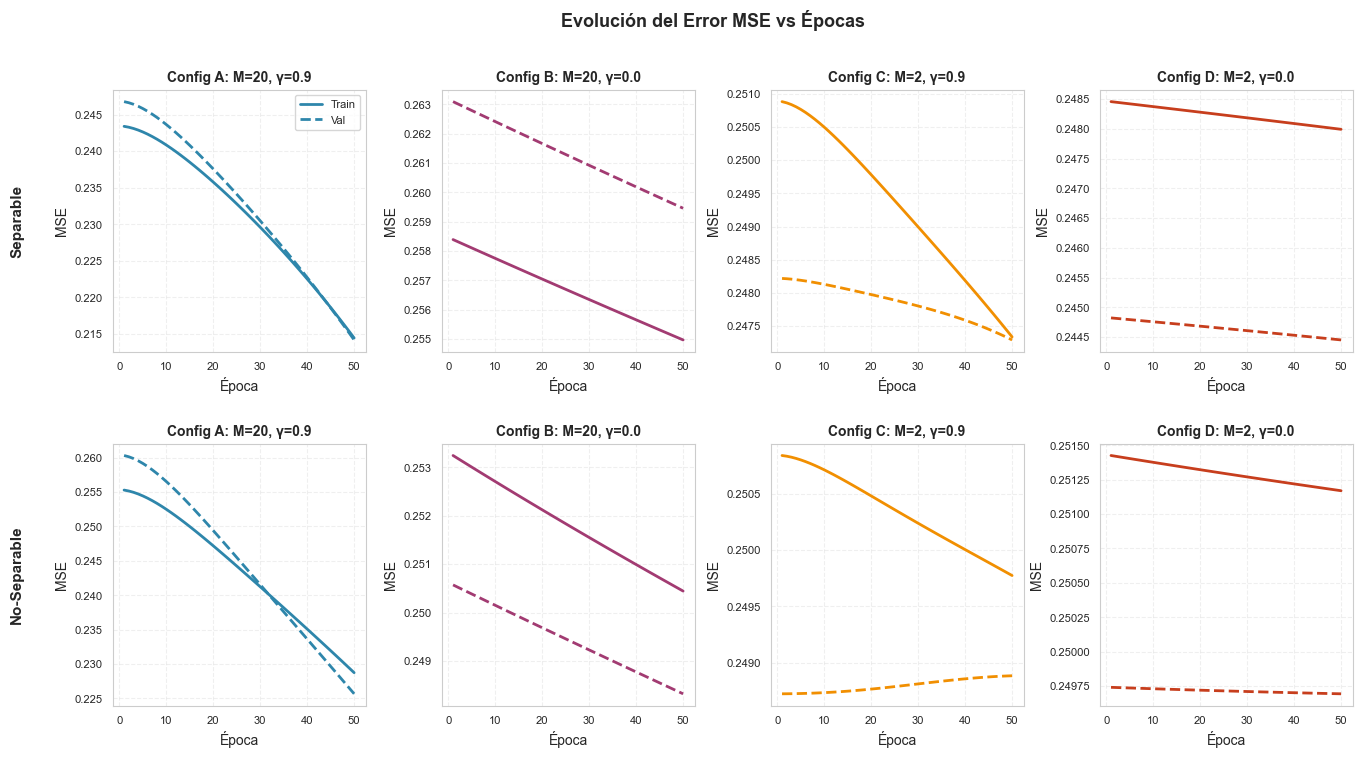

In [12]:
## @brief Genera la matriz 2×4 de curvas de error train/val por configuración.
fig = plot_error_matrix(results_sep, results_nosep,
                        output_path=FIGURES_DIR / 'error_matrix.pdf')
plt.show()

## 2.5 — Tabla de convergencia

In [13]:
## @brief Imprime la tabla de errores finales de validación por configuración.
print_convergence_table(results_sep, results_nosep)
convergence_dataframe(results_sep, results_nosep)


Config        Separable (val)   No-Separable (val)
----------------------------------------------------
Config A             0.214173             0.225668
Config B             0.259459             0.248321
Config C             0.247292             0.248884
Config D             0.244454             0.249694


,config,sep_train,sep_val,nosep_train,nosep_val
0,A,0.214442,0.214173,0.228738,0.225668
1,B,0.254966,0.259459,0.250444,0.248321
2,C,0.247338,0.247292,0.249775,0.248884
3,D,0.247991,0.244454,0.251170,0.249694


---
# Sección 3 — Clasificador de imágenes ACRIMA

Dataset: [ACRIMA en Kaggle](https://www.kaggle.com/datasets/toaharahmanratul/acrima-dataset) — imágenes de fondo de ojo etiquetadas con y sin glaucoma.

In [14]:
## @brief Descarga el dataset ACRIMA desde Kaggle usando kagglehub.
#  La primera ejecución descarga (~1 GB). Las siguientes usan la caché local.
ACRIMA_PATH = kagglehub.dataset_download('toaharahmanratul/acrima-dataset')
print(f'Dataset descargado en: {ACRIMA_PATH}')

Dataset descargado en: /Users/duque/.cache/kagglehub/datasets/toaharahmanratul/acrima-dataset/versions/2


In [15]:
## @brief Carga y normaliza el dataset ACRIMA completo.
#  Normalización L∞ por observación: cada imagen se divide por su valor máximo.
#  Estructura esperada: data_path/{split}/{Glaucoma,Non Glaucoma}/*.jpg
#  Retorna X (n, D) con valores en [0, 1] y T (n,) con etiquetas 0/1.
IMG_SIZE  = (64, 64)
GRAYSCALE = True

def load_acrima(data_path, img_size=IMG_SIZE, grayscale=GRAYSCALE):
    X_list, T_list = [], []
    for root, dirs, files in os.walk(data_path):
        folder = os.path.basename(root).lower()
        if 'glaucoma' not in folder:
            continue
        label = 1 if 'non' not in folder else 0
        for archivo in files:
            if not archivo.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            img = Image.open(os.path.join(root, archivo))
            img = img.convert('L' if grayscale else 'RGB').resize(img_size)
            arr = np.array(img, dtype=np.float32)
            mx  = arr.max()
            if mx > 0:
                arr /= mx
            X_list.append(arr.flatten())
            T_list.append(label)
    return np.array(X_list, dtype=np.float32), np.array(T_list, dtype=np.int32)

X_acrima, T_acrima = load_acrima(ACRIMA_PATH)
print(f'X: {X_acrima.shape}  |  T: {T_acrima.shape}')
print(f'Clases: {np.unique(T_acrima, return_counts=True)}')

assert X_acrima.min() >= 0.0 and X_acrima.max() <= 1.0
print('✓ Normalización L∞ correcta')
D_esperado = IMG_SIZE[0] * IMG_SIZE[1] * (1 if GRAYSCALE else 3)
assert X_acrima.shape[1] == D_esperado
print(f'✓ Dimensión de entrada correcta — D = {D_esperado}')

X: (705, 4096)  |  T: (705,)
Clases: (array([0, 1], dtype=int32), array([309, 396]))
✓ Normalización L∞ correcta
✓ Dimensión de entrada correcta — D = 4096


Accuracy train: 56.2%  |  val: 56.0%


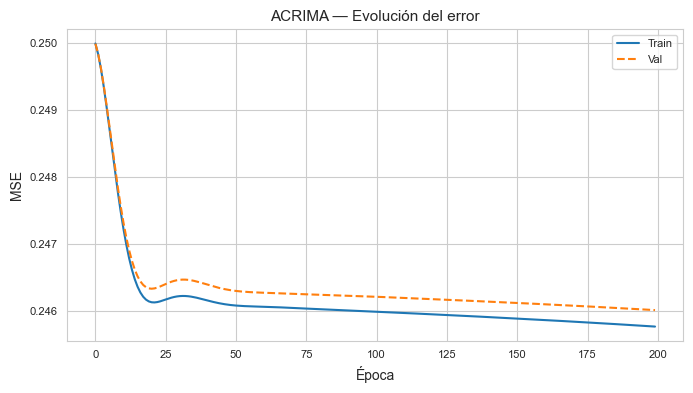

In [16]:
## @brief Entrena MLP sobre ACRIMA con split 80/20 y visualiza la evolución del error.
dev = torch.device(device)

X_tr, X_te, T_tr, T_te = train_test_split(X_acrima, T_acrima, test_size=0.2, random_state=42)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32, device=dev)
X_te_t = torch.tensor(X_te, dtype=torch.float32, device=dev)
T_tr_t = torch.tensor(T_tr, dtype=torch.float32, device=dev).unsqueeze(1)
T_te_t = torch.tensor(T_te, dtype=torch.float32, device=dev).unsqueeze(1)

mlp_acrima = MultilayerPerceptron([X_tr_t.shape[1], 64, 1], alpha=0.01, gamma=0.9, max_weights=0.01)
mlp_acrima.Wo       = mlp_acrima.Wo.to(dev)
mlp_acrima.Ws       = mlp_acrima.Ws.to(dev)
mlp_acrima.dWo_prev = mlp_acrima.dWo_prev.to(dev)
mlp_acrima.dWs_prev = mlp_acrima.dWs_prev.to(dev)

train_err, val_err = mlp_acrima.train_mlp(200, X_tr_t, T_tr_t, X_te_t, T_te_t)

acc_train = (mlp_acrima.predict(X_tr_t).cpu().squeeze() == torch.tensor(T_tr)).float().mean().item()
acc_val   = (mlp_acrima.predict(X_te_t).cpu().squeeze() == torch.tensor(T_te)).float().mean().item()
print(f'Accuracy train: {acc_train*100:.1f}%  |  val: {acc_val*100:.1f}%')

plt.figure(figsize=(7, 4))
plt.plot(train_err, label='Train')
plt.plot(val_err,   label='Val', linestyle='--')
plt.xlabel('Época'); plt.ylabel('MSE')
plt.title('ACRIMA — Evolución del error')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'acrima_error.pdf', bbox_inches='tight')
plt.show()